In [1]:
# Import needed modules (needs yt>=4 version, do pip install 'yt>=4.0' if needed)
# Classical yt plot examples can be found in Cookbook https://yt-project.org/doc/cookbook
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import time as t
import yt
from yt.frontends.boxlib.data_structures import AMReXDataset
yt.set_log_level(0)

In [2]:
# Set working directory
pathname = '/home/marm/Desktop/gempic/build'
pathname_out = pathname + '/processed'
try:
    os.mkdir(pathname_out)
except(FileExistsError):
    pass
os.chdir(pathname)
sim_name = "rho"

In [3]:
# Read data
slices =os.listdir("Plotfiles")
slices.sort()

In [4]:
end = 1000

In [5]:
mass = []

for iteration in range(0, end):
    plotfile = './Plotfiles/{}{:05d}'.format(sim_name, iteration)
    ds = yt.load(plotfile)
    field_data = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    rho = field_data['boxlib', 'rho']
    mass.append(np.sum(rho))


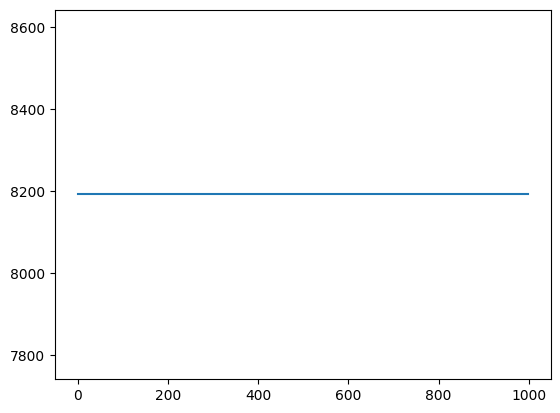

In [6]:
plt.plot(mass[0:end])
plt.show()

In [7]:
rho_mean = []

for iteration in range(0, end):
    plotfile = './Plotfiles/{}{:05d}'.format(sim_name, iteration)
    ds = yt.load(plotfile)
    field_data = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    rho = field_data['boxlib', 'rho']
    rho = rho.reshape(rho.size)
    rho_mean.append(np.dot(rho, rho) - np.mean(rho))

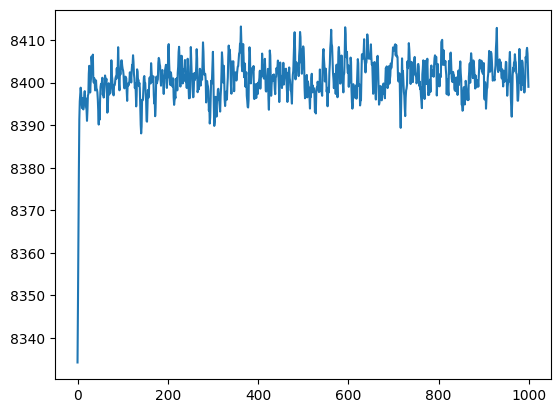

In [8]:
plt.plot(rho_mean[0:end])
plt.show()

In [9]:
rho_square = []

for iteration in range(0, end):
    plotfile = './Plotfiles/{}{:05d}'.format(sim_name, iteration)
    ds = yt.load(plotfile)
    field_data = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    rho = field_data['boxlib', 'rho']
    rho = rho.reshape(rho.size)
    tmp = rho - np.mean(rho)
    rho_square.append(np.dot(tmp, tmp))

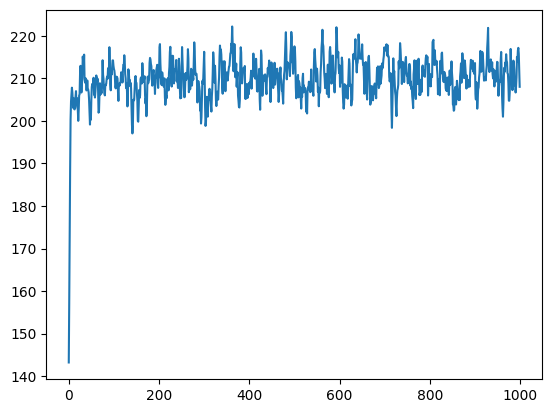

In [10]:
plt.plot(rho_square[0:end])
plt.show()